In [35]:
!pip install -q kaggle

In [36]:
import kagglehub

path = kagglehub.dataset_download("pritpal2873/multiple-skin-disease-detection-and-classification")

print(path)

/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification


In [37]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Show first 5 files
    print("-" * 50)

/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification
Directories: ['Skin Cancer Dataset']
Files: []
--------------------------------------------------
/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification/Skin Cancer Dataset
Directories: ['Acitinic Keratosis', 'Pigmented Benign Keratosis', 'Melanoma', 'Vascular Lesion', 'Squamous Cell Carcinoma', 'Basal Cell Carcinoma', 'Seborrheic Keratosis', 'Dermatofibroma', 'Nevus']
Files: []
--------------------------------------------------
/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification/Skin Cancer Dataset/Acitinic Keratosis
Directories: []
Files: ['ISIC_0059561.jpg', 'ISIC_0069932.jpg', 'ISIC_0065476.jpg', 'ISIC_0057072.jpg', 'ISIC_0054359.jpg']
--------------------------------------------------
/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification/Skin Cancer Dataset/Pigmented Benign Keratosis
Directories: []
F

In [38]:
import os, shutil
from sklearn.model_selection import train_test_split

import os

target_keywords = {
    'Actinic Keratosis': ['actinic', 'acitinic'],   # dataset has a typo in the real folder name
    'Seborrheic Keratosis': ['seborrheic'],
}

class_dirs = {}
for root, dirs, files in os.walk(path):
    for d in dirs:
        low = d.lower()
        for clean_name, kws in target_keywords.items():
            if any(kw in low for kw in kws):
                class_dirs[clean_name] = os.path.join(root, d)

assert len(class_dirs) == 2, f"Expected 2 class dirs, found: {class_dirs}"
print(class_dirs)

base_out = "/content/skin_split"
for split in ['train', 'validation', 'test']:
    for cls in class_dirs:
        os.makedirs(os.path.join(base_out, split, cls), exist_ok=True)

for cls, folder in class_dirs.items():
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=SEED)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)
    for split_name, split_files in [('train', train_files), ('validation', val_files), ('test', test_files)]:
        for f in split_files:
            shutil.copy(os.path.join(folder, f), os.path.join(base_out, split_name, cls, f))
    print(f"{cls}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

train_dir = os.path.join(base_out, 'train')
val_dir   = os.path.join(base_out, 'validation')
test_dir  = os.path.join(base_out, 'test')

{'Actinic Keratosis': '/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification/Skin Cancer Dataset/Acitinic Keratosis', 'Seborrheic Keratosis': '/kaggle/input/datasets/pritpal2873/multiple-skin-disease-detection-and-classification/Skin Cancer Dataset/Seborrheic Keratosis'}
Actinic Keratosis: train=350, val=75, test=75
Seborrheic Keratosis: train=350, val=75, test=75


In [39]:
# STEP: Imports + reproducibility

import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

results_dir = "results/skin_lesion_lab/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs('models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}' if gpus else 'No GPU — training on CPU (slower).')

TensorFlow version: 2.20.0
GPUs available: 2


In [40]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

In [41]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
    label_mode='binary',
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

class_names = train_dataset.class_names 
num_classes = len(class_names)
print(f'Classes: {class_names}')

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Classes: ['Actinic Keratosis', 'Seborrheic Keratosis']


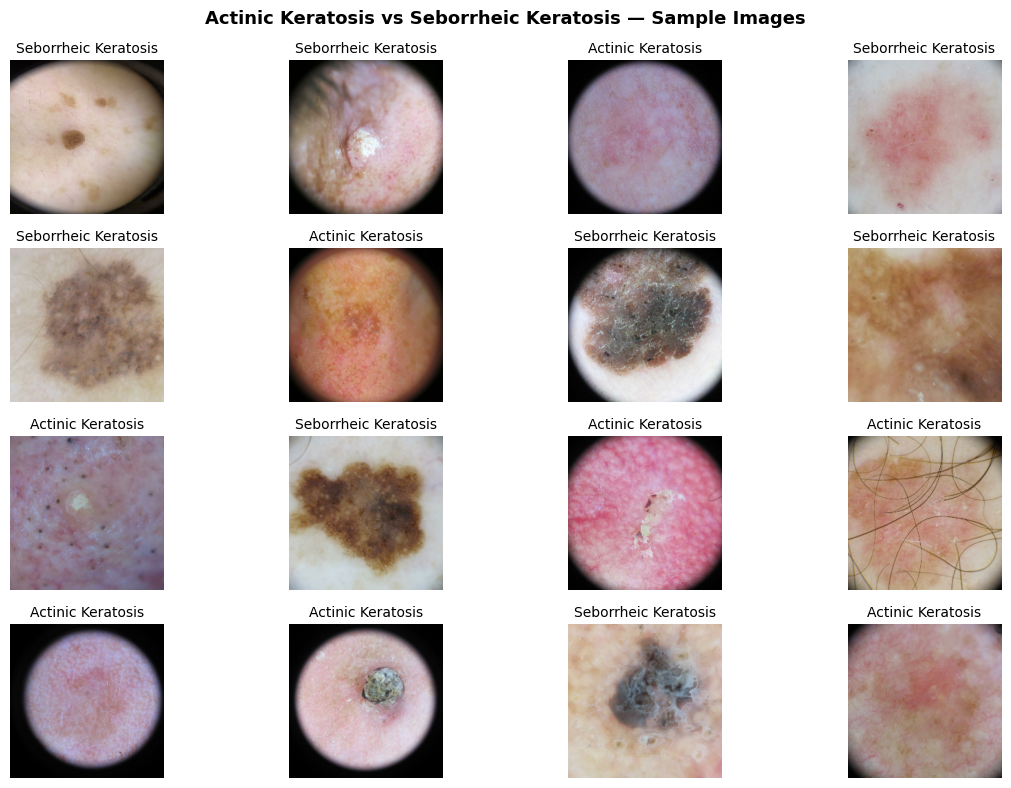

In [42]:
# STEP 3: Sanity-check a batch visually — catches wrong labels / corrupted files before you waste an hour training
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Actinic Keratosis vs Seborrheic Keratosis — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
# STEP 4: Pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [44]:
# STEP 5: Augmentation
# augment dataset to contain rotated_by_X / translation / flip / saltandpepper copies
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

In [45]:
# STEP 6: Callbacks
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Binary evaluation — single sigmoid output, threshold at 0.5."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return accuracy_score(y_true, y_pred)

In [46]:
def build_transfer_model(input_shape, augmentation, base_trainable=False):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base_model.trainable = base_trainable

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='efficientnet_transfer')

cnn_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('efficientnet_transfer'), verbose=1,
    class_weight=class_weight_dict,
)

Epoch 1/50


E0000 00:00:1785238028.795458      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 277ms/step - accuracy: 0.5829 - loss: 0.6866 - val_accuracy: 0.7067 - val_loss: 0.6171 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.6557 - loss: 0.6240 - val_accuracy: 0.7200 - val_loss: 0.5686 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.7014 - loss: 0.5795 - val_accuracy: 0.7600 - val_loss: 0.5416 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7200 - loss: 0.5558 - val_accuracy: 0.7400 - val_loss: 0.5240 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7157 - loss: 0.5474 - val_accuracy: 0.7600 - val_loss: 0.5101 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.7243 - loss: 0.5323 - val_accuracy: 0.7467 - val_loss: 0.5021 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.7114 - loss: 0.5474 - val_accuracy: 

Custom CNN -> val_loss: 0.4101, val_accuracy: 0.8133


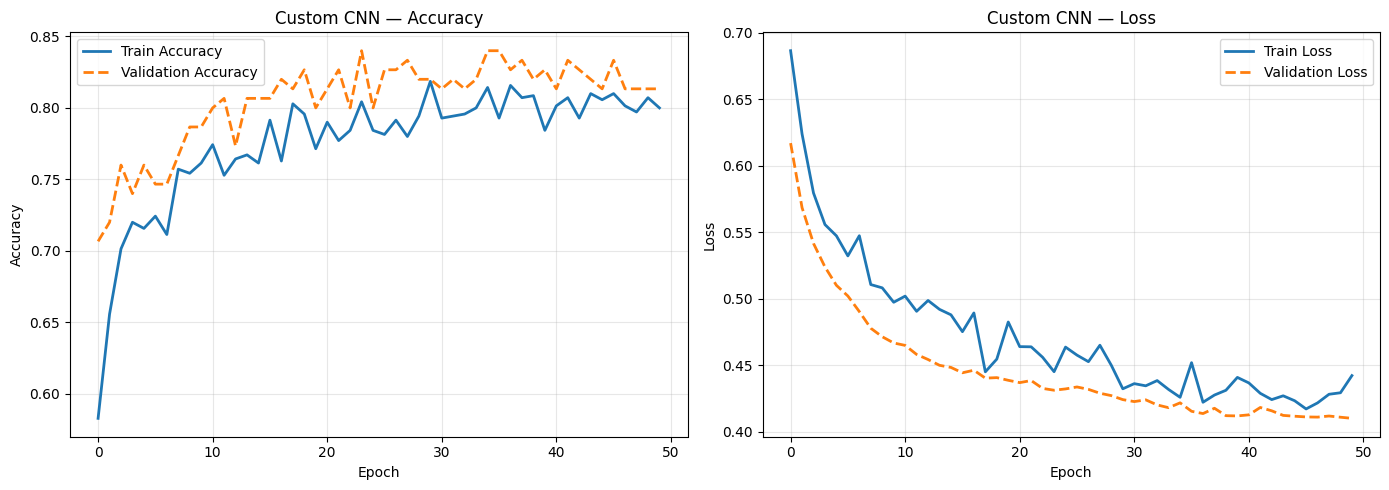

2026-07-28 11:29:06.565322: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Custom CNN
Accuracy : 0.8067
Precision: 0.7447
Recall   : 0.9333
F1-Score : 0.8284

Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis     0.9107    0.6800    0.7786        75
Seborrheic Keratosis     0.7447    0.9333    0.8284        75

            accuracy                         0.8067       150
           macro avg     0.8277    0.8067    0.8035       150
        weighted avg     0.8277    0.8067    0.8035       150



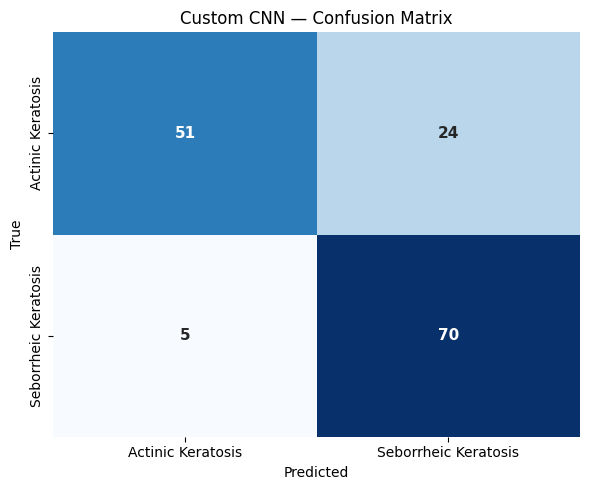

In [48]:
# STEP: Evaluate
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}, val_accuracy: {cnn_val_acc:.4f}')

plot_learning_curves(cnn_history, 'Custom CNN')
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')

In [50]:
# Save class centroids for OOD rejection
gap_layer = next(l for l in cnn_model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D))
embedding_model = tf.keras.Model(cnn_model.input, gap_layer.output)

centroids = {}
for cls_idx, cls_name in enumerate(class_names):
    embs = []
    for images, labels in train_dataset.unbatch().batch(32):
        mask = labels.numpy().ravel() == cls_idx
        if mask.any():
            e = embedding_model.predict(images.numpy()[mask], verbose=0)
            embs.append(e)
    centroids[cls_name] = np.concatenate(embs).mean(axis=0)

np.save('models/class_centroids.npy', centroids, allow_pickle=True)
print("Saved centroids for:", list(centroids.keys()))

2026-07-28 11:32:44.019208: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-28 11:32:49.163068: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Saved centroids for: ['Actinic Keratosis', 'Seborrheic Keratosis']
